# 120. Chatbot - seq2seq language model

### Encoder-Decoder model

- Chatbot_data_for_Korean v1.0 dataset (https://github.com/songys/Chatbot_data) 을 이용한 Chatbot model 개발

- 챗봇 트레이닝용 문답 페어 11,876개  
- 일상다반서 0, 이별(부정) 1, 사랑(긍정) 2로 레이블링  

<img src='https://github.com/ironmanciti/NLP_Lecture/raw/master/chatbot.png' width=600>

In [1]:
import os
import sys
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD

In [2]:
BATCH_SIZE = 64
EPOCHS = 100
LATENT_DIM = 64                # encoding space 의 latent dimensionality
MAX_NUM_WORDS = 10000
EMBEDDING_DIM = 100

In [3]:
df = pd.read_csv('data/ChatbotData.csv')
df.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [5]:
df.iloc[:, [0, 1]].values

array([['12시 땡!', '하루가 또 가네요.'],
       ['1지망 학교 떨어졌어', '위로해 드립니다.'],
       ['3박4일 놀러가고 싶다', '여행은 언제나 좋죠.'],
       ...,
       ['흑기사 해주는 짝남.', '설렜겠어요.'],
       ['힘든 연애 좋은 연애라는게 무슨 차이일까?', '잘 헤어질 수 있는 사이 여부인 거 같아요.'],
       ['힘들어서 결혼할까봐', '도피성 결혼은 하지 않길 바라요.']], dtype=object)

In [6]:
input_texts = []
target_texts_inputs = []
target_texts = []

for Q, A in df.iloc[:, [0, 1]].values:
    input_texts.append(Q)
    
    target_text_input = '<sos> ' + A
    target_text = A + ' <eos>'
    
    target_texts_inputs.append(target_text_input)  
    target_texts.append(target_text)

In [7]:
print("Original Input :")
print(input_texts[1100:1110])
print("\nTeacher Forcing Input :")
print(target_texts_inputs[1100:1110])
print("\nTeacher Forcing Target")
print(target_texts[1100:1110])

Original Input :
['다 그만 두고 싶다', '다 그만하고싶어', '다 끝나가니 좋을줄만 알았는데.', '다 나 좋아했으면 좋겠어', '다 내 잘못이지', '다 내 잘못인 것 같아', '다 때려 치우고 싶어', '다 마음에 안 들어', '다 알고 있을까?', '다 잘 될거야']

Teacher Forcing Input :
['<sos> 잠시 쉬어도 괜찮아요.', '<sos> 잠시 쉬어도 괜찮아요.', '<sos> 마음이 허전하신가봐요.', '<sos> 꿈같은 이야기네요.', '<sos> 아니에요. 너무 자책하지 마세요.', '<sos> 아니에요. 너무 자책하지 마세요.', '<sos> 많이 지치고 힘든가봅니다.', '<sos> 그럴 때가 있죠.', '<sos> 다 알 수는 없어요.', '<sos> 다 잘 될 거예요.']

Teacher Forcing Target
['잠시 쉬어도 괜찮아요. <eos>', '잠시 쉬어도 괜찮아요. <eos>', '마음이 허전하신가봐요. <eos>', '꿈같은 이야기네요. <eos>', '아니에요. 너무 자책하지 마세요. <eos>', '아니에요. 너무 자책하지 마세요. <eos>', '많이 지치고 힘든가봅니다. <eos>', '그럴 때가 있죠. <eos>', '다 알 수는 없어요. <eos>', '다 잘 될 거예요. <eos>']


## Tokenization

- language 가 2 개 이므로 언어별로 서로 다른 tokenizer 생성. 따라서, 2 개의 word_index 구성

### Input Text 의 tokenize

In [8]:
input_texts[1500:1505]

['만나기만 하면 싸워', '만나기만 하면 싸워', '만나기만 하면 자꾸 싸우게돼', '만나는게 싫지는 않아', '만나면 싸워']

In [9]:
tokenizer_inputs = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer_inputs.fit_on_texts(input_texts)

input_sequences = tokenizer_inputs.texts_to_sequences(input_texts)

In [10]:
word2idx_inputs = tokenizer_inputs.word_index
print(f'unique input token 수 : {len(word2idx_inputs)}')

num_words_inputs = min(MAX_NUM_WORDS, len(word2idx_inputs) + 1)
print("Input Text 의 단어 수 :", num_words_inputs)

max_len_input = max(len(s) for s in input_sequences)
print("Input Text 의 최대 길이 :", max_len_input)

unique input token 수 : 13398
Input Text 의 단어 수 : 10000
Input Text 의 최대 길이 : 13


### Target Text 의 tokenize 

In [11]:
print(target_texts_inputs[1500:1504])
print(target_texts[1500:1504])

['<sos> 성격이 안 맞나봐요.', '<sos> 만나지 마세요.', '<sos> 성격이 안 맞나봐요.', '<sos> 그러면 만나는게 좋은거 같아요.']
['성격이 안 맞나봐요. <eos>', '만나지 마세요. <eos>', '성격이 안 맞나봐요. <eos>', '그러면 만나는게 좋은거 같아요. <eos>']


### input language 의 tokenize
- 주의 사항 : $<sos>, <eos>$때문에 special character 를 filtering 하면 안됨

In [12]:
tokenizer_targets = Tokenizer(num_words=MAX_NUM_WORDS, filters="")
tokenizer_targets.fit_on_texts(target_texts + target_texts_inputs) 

target_sequences_inputs = tokenizer_targets.texts_to_sequences(target_texts_inputs)
target_sequences = tokenizer_targets.texts_to_sequences(target_texts)

print(target_sequences_inputs[1500:1504])
print(target_sequences[1500:1504])

[[2, 496, 24, 2417], [2, 249, 14], [2, 496, 24, 2417], [2, 287, 1411, 2418, 6]]
[[496, 24, 2417, 1], [249, 14, 1], [496, 24, 2417, 1], [287, 1411, 2418, 6, 1]]


### output language 의 tokenize

In [13]:
word2idx_target = tokenizer_targets.word_index
print(f'unique output tokens : {len(word2idx_target)}')

num_words_target = len(word2idx_target) +1
print("Target Text 의 단어 수 :", num_words_target)

max_len_target = max(len(s) for s in target_sequences)
print("Target Text 의 최대 길이 :", max_len_target)

unique output tokens : 10007
Target Text 의 단어 수 : 10008
Target Text 의 최대 길이 : 22


## sequence padding


#### 주의 사항
- encoder 는 thought vector 생성 목적이므로 default (pre) 로 padding

- decoder 는 teacher forcing 을 해야하므로 post 로 padding

In [14]:
encoder_inputs = pad_sequences(input_sequences, maxlen=max_len_input)
print("encoder input shape :", encoder_inputs.shape)
print("encoder_inputs[0] : ", encoder_inputs[1500])

decoder_inputs = pad_sequences(target_sequences_inputs, maxlen=max_len_target, padding="post")
print("\ndecoder input shape :", decoder_inputs.shape)
print("decoder_inputs[0] : ", decoder_inputs[1500])

decoder_targets = pad_sequences(target_sequences, maxlen=max_len_target, padding="post")
print("\nencoder target shape :", decoder_targets.shape)
print("encoder_targets[0] : ", decoder_targets[1500])

encoder input shape : (11823, 13)
encoder_inputs[0] :  [   0    0    0    0    0    0    0    0    0    0 2007  145  739]

decoder input shape : (11823, 22)
decoder_inputs[0] :  [   2  496   24 2417    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

encoder target shape : (11823, 22)
encoder_targets[0] :  [ 496   24 2417    1    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [25]:
# create embedding layer
embedding_layer = Embedding(MAX_NUM_WORDS + 1, EMBEDDING_DIM)

## Build the model

- encoder 와 decoder 의 embedding, lstm 및 dense layer 를 training 할 목적의 model 작성  

- encoder 는 decoder 에 states [h, c] 만 전달

- prediction 을 위한 model 은 training model 에서 만들어진 layer 들의 weight 를 이용하여 별도 작성  

### Training : Encoder + Teacher Forcing model

In [26]:
# Encoder
encoder_inputs_ = Input(shape=(max_len_input,), name='Encoder_Input')

# pre-trained embedding layer 사용
x = embedding_layer(encoder_inputs_)

encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True)(x)

# encoder 는 hidden state and cell state 만 decoder 로 전달 --> thought vector
encoder_states = [h, c]

# Decoder
# decoder 는 [h, c] 를 initial state 로 사용
decoder_inputs_ = Input(shape=(max_len_target,), name='Decoder_Input')

# decode word embedding 은 pre-trained vector 를 사용 않음
decoder_embedding = Embedding(num_words_target, LATENT_DIM)
decoder_inputs_x = decoder_embedding(decoder_inputs_)

decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)

decoder_outputs, _, _ = decoder_lstm( decoder_inputs_x, initial_state=encoder_states)

# final layer
decoder_dense = Dense(num_words_target, activation='softmax', name='Decoder_Output')
decoder_outputs = decoder_dense(decoder_outputs)

# Create the model object
model = Model([encoder_inputs_, decoder_inputs_], decoder_outputs)

#Compile the model and train it
model.compile(
  optimizer='rmsprop',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

model.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Encoder_Input (InputLayer)      [(None, 13)]         0                                            
__________________________________________________________________________________________________
Decoder_Input (InputLayer)      [(None, 22)]         0                                            
__________________________________________________________________________________________________
embedding_2 (Embedding)         (None, 13, 100)      1000100     Encoder_Input[0][0]              
__________________________________________________________________________________________________
embedding_3 (Embedding)         (None, 22, 64)       640512      Decoder_Input[0][0]              
____________________________________________________________________________________________

In [27]:
EPOCHS = 40

history = model.fit([encoder_inputs, decoder_inputs], decoder_targets, batch_size=BATCH_SIZE, epochs=EPOCHS, 
                   validation_split=0.2)

Train on 9458 samples, validate on 2365 samples
Epoch 1/40
9458/9458 [==============================] - 22s 2ms/sample - loss: 2.9927 - accuracy: 0.7858 - val_loss: 1.8238 - val_accuracy: 0.7854
Epoch 2/40
9458/9458 [==============================] - 18s 2ms/sample - loss: 1.3716 - accuracy: 0.8369 - val_loss: 1.7822 - val_accuracy: 0.8042
Epoch 3/40
9458/9458 [==============================] - 18s 2ms/sample - loss: 1.2975 - accuracy: 0.8395 - val_loss: 1.7525 - val_accuracy: 0.8048
Epoch 4/40
9458/9458 [==============================] - 17s 2ms/sample - loss: 1.2624 - accuracy: 0.8400 - val_loss: 1.7695 - val_accuracy: 0.8048
Epoch 5/40
9458/9458 [==============================] - 17s 2ms/sample - loss: 1.2368 - accuracy: 0.8406 - val_loss: 1.7901 - val_accuracy: 0.8023
Epoch 6/40
9458/9458 [==============================] - 18s 2ms/sample - loss: 1.2144 - accuracy: 0.8420 - val_loss: 1.7831 - val_accuracy: 0.7996
Epoch 7/40
9458/9458 [==============================] - 18s 2ms/sample

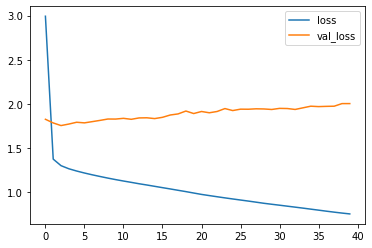

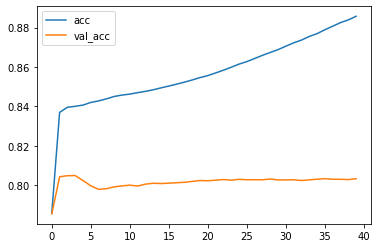

In [28]:
# plot some data
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

# accuracies
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [29]:
# save model
model.save('s2s.h5')

### Make Predictions - Inference phase

- prediction 을 위한 별도의 encoder model 
- encoder 의 states 를 initial state 로 받는 decoder model 작성  

- encoder 는 training 단계와 동일하게 input_text 를 입력으로 받고 encoder_states 를 출력으로 하므로 이전에 define 한 encoder_input_ 과 encoder_states 변수 재사용

In [30]:
# Encoder
encoder_model = Model(encoder_inputs_, encoder_states)

# Decoder
decoder_state_input_h = Input(shape=(LATENT_DIM,), name='Decoder_hidden_h')
decoder_state_input_c = Input(shape=(LATENT_DIM,), name='Decoder_hidden_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='Decoder_input')
x = decoder_embedding(decoder_inputs_single)

# output, hidden states 를 저장
decoder_outputs, h, c = decoder_lstm(x, initial_state=decoder_states_inputs)

decoder_states = [h, c]

decoder_outputs = decoder_dense(decoder_outputs)  

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,    #decoder_model.predict([target_seq] + states_value)
    [decoder_outputs] + decoder_states
)

encoder_model.summary()

decoder_model.summary()

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Encoder_Input (InputLayer)   [(None, 13)]              0         
_________________________________________________________________
embedding_2 (Embedding)      (None, 13, 100)           1000100   
_________________________________________________________________
lstm_2 (LSTM)                [(None, 64), (None, 64),  42240     
Total params: 1,042,340
Trainable params: 1,042,340
Non-trainable params: 0
_________________________________________________________________
Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Decoder_input (InputLayer)      [(None, 1)]          0                                            
_________________________________________________________________

In [31]:
# reverse word2idx dictionary to get back words during prediction
idx2word_eng = {v:k for k, v in word2idx_inputs.items()}
print(list(idx2word_eng.items())[:20])
print()

idx2word_trans = {v:k for k, v in word2idx_target.items()}
print(list(idx2word_trans.items())[:20])

[(1, '너무'), (2, '좋아하는'), (3, '거'), (4, '싶어'), (5, '같아'), (6, '안'), (7, '나'), (8, '좀'), (9, '사람'), (10, '내가'), (11, '싶다'), (12, '어떻게'), (13, '썸'), (14, '왜'), (15, '내'), (16, '사람이'), (17, '이별'), (18, '것'), (19, '잘'), (20, '없어')]

[(1, '<eos>'), (2, '<sos>'), (3, '거예요.'), (4, '수'), (5, '더'), (6, '같아요.'), (7, '좋은'), (8, '있어요.'), (9, '잘'), (10, '있을'), (11, '많이'), (12, '것'), (13, '게'), (14, '마세요.'), (15, '해보세요.'), (16, '건'), (17, '수도'), (18, '거'), (19, '마음이'), (20, '좋을')]


In [32]:
def decode_sequence(input_seq):
   # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)

   # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1))

   # target sequence 의 첫번째 character 를 start character (<sos>) 로 설정 
   # [[2.]]
    target_seq[0, 0] = word2idx_target['<sos>']

   # <eos> 가 decode 에서 생성되면 break
    eos = word2idx_target['<eos>']

   # Create the translation
    output_sentence = []
    for _ in range(max_len_target):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

       # argmax 로 가장 확률 높은 단어 선택 --> greedy selection
        idx = np.argmax(output_tokens[0, 0, :])

        if eos == idx:  # End sentence of EOS
            break

        word = ''
        if idx > 0:      # idx 0 은 zero padding 된 sequence 이므로 skip
            word = idx2word_trans[idx]
            output_sentence.append(word)

        # 생성된 word 를 decoder 의 다음 input 으로 사용
        target_seq[0, 0] = idx

       # Update states
        states_value = [h, c]

    return ' '.join(output_sentence)

for _ in range(5):
    i = np.random.choice(len(input_texts))
    input_seq = encoder_inputs[i:i+1]
    
    translation = decode_sequence(input_seq)
    print('-')
    print('질문 :', input_texts[i])
    print('답변 : ', translation)

-
질문 : 좋아하는 애 친구한테 다같이 만나자고 말해도 돼?
답변 :  왜 언제나 좋은 곳으로 가보세요.
-
질문 : 연락 문제로 지쳐가
답변 :  성공을 기원합니다.
-
질문 : 퇴근하고 만나자고 말해볼까
답변 :  잠시 눈을 신경쓰지 마세요.
-
질문 : 입냄새가 고민이야.
답변 :  절대 항상 좋죠.
-
질문 : 코 세워 볼까
답변 :  안해도 괜찮아요.


In [33]:
txt = "사랑 ?"
input_sequence = tokenizer_inputs.texts_to_sequences([txt])
encoder_input = pad_sequences(input_sequence, maxlen=max_len_input)

translation = decode_sequence(encoder_input)
print('-')
print('질문', txt)
print('답변:', translation)

-
질문 사랑 ?
답변: 네


In [34]:
print("챗봇 대화 시작 .....")

while True:
    inp = input("질문 : ")
    if inp.lower() == "quit":
        break
    
    input_sequence = tokenizer_inputs.texts_to_sequences([inp])
    encoder_input = pad_sequences(input_sequence, maxlen=max_len_input)

    answer = decode_sequence(encoder_input)

    print("답변 : ", answer)

챗봇 대화 시작 .....
질문 : 안녕하세요
답변 :  안녕하세요.
질문 : 이름이 뭐야?
답변 :  단맛도 있을 거예요.
질문 : 단맛을 좋아해?
답변 :  네 물어보세요.
질문 : 묻고 있잖아 ㅋ
답변 :  안녕하세요.
질문 : 취미가 뭐야?
답변 :  그럴 수 있어요.
질문 : quit
